### Import Modules

In [1]:
import pandas as pd,numpy as np
from sklearn.cluster import DBSCAN
from ai_patterns_mining import Config
from sklearn.metrics import pairwise_distances
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import umap
from ai_patterns_mining import parse_json_safe
import getpass,os
from langchain.chat_models import init_chat_model
from tqdm import tqdm

/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config = Config(tag="prompt & rag",run_output="20251028_085918 - Run ")

In [3]:
data = pd.read_csv(config.PATTERN_EMBEDDINGS_FILE)

In [4]:
data.shape

(349, 775)

In [5]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,765,766,767,Pattern Name,Problem,Context,Solution,Result,Uses,Description
0,-0.016995,0.026468,0.025532,-0.067473,0.002525,0.011732,-0.007041,0.019831,0.006295,0.001967,...,0.024486,0.044043,-0.016385,External Knowledge Augmentation,Large Language Models (LLMs) are bounded by th...,LLMs relying on fixed and parametric knowledge...,Augment LLMs with the capability to access ext...,LLMs can surpass traditional knowledge limitat...,"Accessing contemporary information, retrieving...","LLM Augmentation, External Tools, Dynamic Know..."
1,-0.017687,0.023443,0.027102,-0.067931,0.005764,0.014262,-0.000045,0.020386,0.008661,0.000175,...,0.028134,0.049190,-0.014502,Domain-Specific Tool Integration,"LLMs, trained on general knowledge, often exhi...",LLMs needing to perform tasks requiring deep e...,Employ specific external tools like online cal...,"Mitigates the expertise gap in LLMs, enhancing...","Performing complex calculations, solving equat...","LLM Augmentation, External Tools, Dynamic Know..."
2,-0.014345,0.017344,0.023612,-0.056745,0.004501,0.007804,0.006136,0.019828,0.004082,0.012418,...,0.024810,0.030816,-0.020411,Task Automation via Tools,LLMs are fundamentally language processors and...,Users requiring LLMs to perform real-world act...,Integrate LLMs with external task automation t...,LLMs can facilitate the execution of external ...,"Scheduling appointments, setting reminders, fi...","LLM Integration, External Tools, Task Automati..."
3,-0.026486,0.023429,0.009343,-0.069543,0.010299,0.014088,-0.016041,0.022546,0.015741,0.001970,...,0.026607,0.038820,-0.015099,Multimodal Interaction Augmentation,LLMs often struggle to consistently understand...,User interactions involving varied input types...,Deploy specialized tools like speech recogniti...,Improved understanding and response to a broad...,"Understanding speech inputs, analyzing images,...","Multimodal Inputs, LLM Augmentation, Specializ..."
4,-0.022221,0.015212,0.029252,-0.054646,0.004160,0.011879,-0.014501,0.028994,0.021275,-0.002289,...,0.020145,0.031651,-0.028700,Transparent Tool-Use Reasoning,The opaque 'black-box' nature of current LLMs ...,"LLM applications where interpretability, accou...",Utilize tool learning to enable LLMs to exhibi...,"More transparent LLM operations, allowing user...","Explaining complex problem-solving steps, debu...","LLM Transparency, Tool Use, Reasoning Process,..."


In [6]:
pattern_cols = ["Pattern Name","Problem","Context","Solution","Result","Uses","Description"]
features_cols = [i for i in data.columns.tolist() if i not in pattern_cols]
embeddings = data[features_cols]
Y = data["Pattern Name"].tolist()

### PCA & Analysis

In [7]:
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

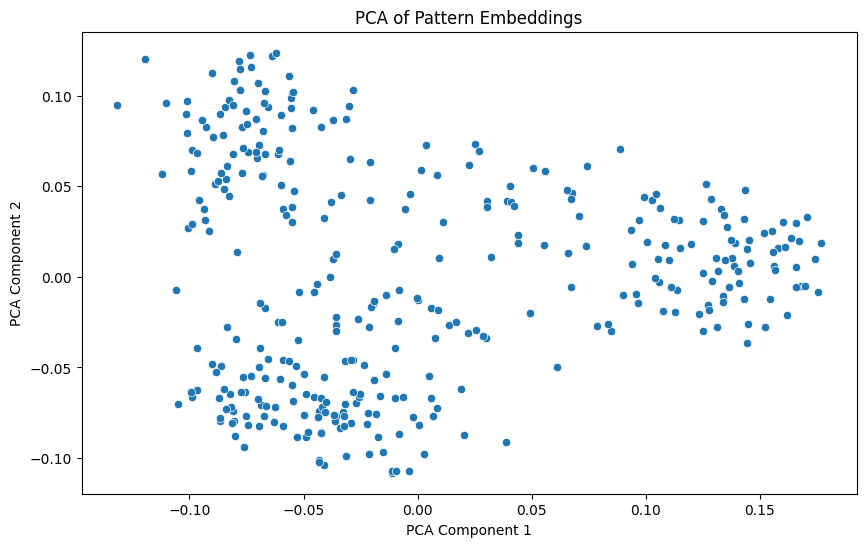

In [8]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=embeddings_2d[:,0], y=embeddings_2d[:,1])
plt.title("PCA of Pattern Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [9]:
emb_umap = umap.UMAP(n_neighbors=15, min_dist=0.1).fit_transform(embeddings)

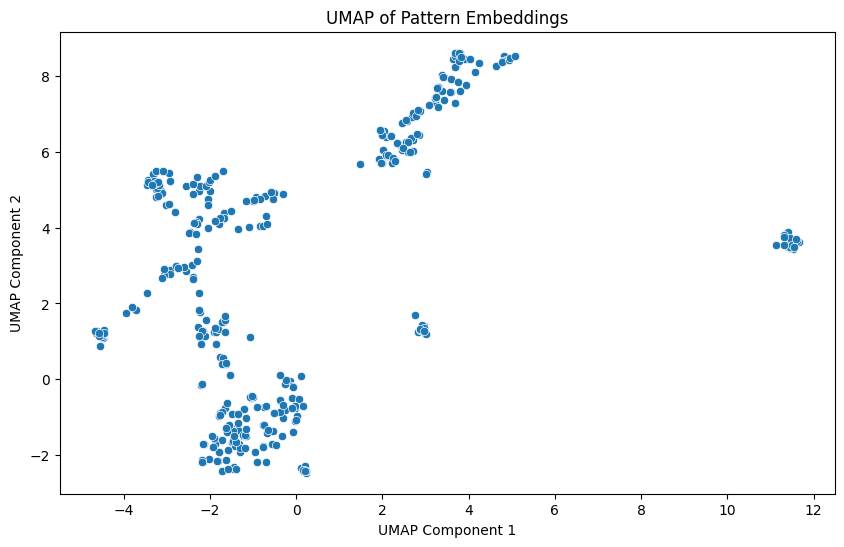

In [10]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=emb_umap[:,0], y=emb_umap[:,1])
plt.title("UMAP of Pattern Embeddings")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.show()

### Nearest Patterns

In [11]:
from sklearn.metrics.pairwise import cosine_distances


In [12]:
center = [0]*embeddings.iloc[0].shape[0]

In [13]:
distances = []

for _, row in embeddings.iterrows():
    dist = cosine_distances([center], [row.tolist()])[0][0]
    distances.append(dist)

In [14]:
distances

[np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float6

In [15]:
distances = pairwise_distances(embeddings, metric='cosine')

for i in range(len(Y)):
    dists = distances[i]
    nearest_indices = np.argsort(dists)[1:20]
    nearest_patterns = [(Y[idx], dists[idx]) for idx in nearest_indices]
    print(f"Pattern: {Y[i]}")
    for pattern, dist in nearest_patterns:
        print(f"  Nearest: {pattern}, Distance: {dist:.4f}")
    print()

Pattern: External Knowledge Augmentation
  Nearest: Domain-Specific Tool Integration, Distance: 0.0205
  Nearest: Robust Tool-Augmented Processing, Distance: 0.0330
  Nearest: Knowledge Augmentation, Distance: 0.0344
  Nearest: Plug-and-Play LLM Module, Distance: 0.0388
  Nearest: Retrieval Augmented Generation (RAG), Distance: 0.0394
  Nearest: ReACT (Reasoning and Acting), Distance: 0.0407
  Nearest: Tool-Augmented Response Synthesis, Distance: 0.0409
  Nearest: Retrieval Augmented Generation (RAG) - Inference, Distance: 0.0449
  Nearest: Retrieval-Augmented Generation (RAG), Distance: 0.0498
  Nearest: Retriever-Aware Training (RAT), Distance: 0.0507
  Nearest: Contextual Prompt Engineering, Distance: 0.0510
  Nearest: Parametric and Non-Parametric Memory Combination, Distance: 0.0518
  Nearest: InContext Retrieval-Augmented Language Modeling (InContext RALM), Distance: 0.0561
  Nearest: ReAct (Reasoning and Acting), Distance: 0.0574
  Nearest: Reasoning-Action Synchronization, Dist

### Aggromelative Clustering

In [46]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=None, distance_threshold=0.4)
labels = model.fit_predict(embeddings)


In [47]:
labels

array([27,  3, 25, 24,  4,  4,  2, 40, 40, 40,  2, 24, 29,  2, 31,  9,  4,
        9, 32, 29,  6, 32, 32, 17, 30, 16,  0, 41, 10, 10, 10, 10, 33, 33,
       19,  7, 10, 15, 39, 25, 43, 43,  9, 34, 37,  4, 24, 30,  6, 25,  5,
       32,  9, 18, 12, 36, 19, 15, 28,  4, 13, 10, 10, 19, 33,  2, 29, 29,
       29,  9, 19,  4, 23, 23,  2, 31, 17,  7, 22,  2,  1, 14, 18, 29, 24,
        0, 34,  9, 15, 18, 43,  1, 14, 37, 29, 15, 39, 28,  6, 32,  7, 17,
        0, 13, 11, 16, 27, 28, 31, 36,  0,  0, 12, 12,  2, 11, 31,  3,  1,
       19, 33,  4, 19, 11, 18,  4,  4, 20,  3, 11, 17, 24, 22,  0,  3, 13,
       22, 11, 12, 11, 31, 25, 11, 11, 39, 31, 11, 39,  8,  8,  8,  8,  8,
        8,  8, 17, 28, 10, 16, 16, 44,  5,  6, 18, 32,  5,  5,  9, 32, 28,
        9, 21,  9, 39,  0,  0, 15,  3, 19, 20,  4,  4, 22,  7,  5,  0, 27,
        4, 29, 34, 14, 28, 36, 22, 27, 16,  3, 31,  0, 12,  3, 12, 31, 35,
        9, 35, 43, 43,  5,  5, 11, 34, 22, 29, 38, 38, 10,  5, 32, 32, 27,
       32,  2, 29, 14,  4

### Compare patterns using LLMs

In [11]:

if not os.environ.get("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter API key for Google Gemini: ")

llm = init_chat_model("gemini-2.5-flash", model_provider="google_genai", temperature=0)


In [126]:
pattern_comparing_prompt = """\
You are an expert in AI design pattern analysis and comparison.

Compare the following two AI design patterns and determine whether to keep, remove, or combine them. 
Focus on identifying overlap, uniqueness, and usefulness in practical AI system design.

Pattern 01:
{pattern1}

Pattern 02:
{pattern2}

Respond strictly in the following JSON format:

  "remove": "pattern 01" | "pattern 02" | "both" | "none",
  "can_combine": true | false,
  "combined_pattern_suggestion":
    "Pattern Name": "<string>",
    "Problem": "<string>",
    "Context": "<string>",
    "Solution": "<string>",
    "Result": "<string>",
    "Uses": "<string>"
  ,
  "think": "<reasoning for the decision>"

**Decision rules:**
- If both patterns are valuable and distinct → `"remove": "none"`, `"can_combine": false`.
- If both patterns describe the same thing but one is more comprehensive → remove the less useful one. => `"remove": "pattern 01"` or `"remove": "pattern 02"`. can_combine: false.
- If one pattern is redundant or weaker → remove the less useful one.
- If both are address same concept in different ways and can merge into a stronger unified pattern → `"remove": "both"`, `"can_combine": true`.
- If both solve different problems or contexts → `"remove": "none"`.
- Prefer keeping existing patterns rather than creating new combined ones.
- Only include `combined_pattern_suggestion` if `"can_combine": true`; otherwise, leave it empty or omit it.
- Do not include any explanation outside the JSON output.

"""

pattern_comparing_prompt = pattern_comparing_prompt.replace("""\"think": "<reasoning for the decision>\"""", "")

In [127]:
def compare_patterns(pattern1, pattern2):
    log_file = "./logs/pattern_comparison_log.txt"
    os.makedirs(os.path.dirname(log_file), exist_ok=True)
    f = open(log_file,"a")
    f.write("="*100+f"\nComparing Patterns:\nPattern 01: {pattern1}\nPattern 02: {pattern2}\n")
    prompt = pattern_comparing_prompt.format(pattern1=pattern1, pattern2=pattern2)
    response = llm.invoke(prompt)
    f.write(f"LLM Response: {response.content}\n\n")
    return parse_json_safe(response.content,delimiter="{}")

In [91]:
def df_to_pattern_dict(df):
    return {
        "Pattern Name": df["Pattern Name"].values[0],
        "Problem": df["Problem"].values[0],
        "Context": df["Context"].values[0],
        "Solution": df["Solution"].values[0],
        "Result": df["Result"].values[0],
        "Uses": df["Uses"].values[0],
    }

### Distance Measures

In [9]:
distances = pairwise_distances(embeddings, metric='cosine')
print("Min distance:", np.min(distances)
      ,"\nMax distance:", np.max(distances)
      ,"\nMean distance:", np.mean(distances)
      ,"\nMedian distance:", np.median(distances)
)

Min distance: 0.0 
Max distance: 0.2852025495841255 
Mean distance: 0.15599853286657397 
Median distance: 0.15650054720998852


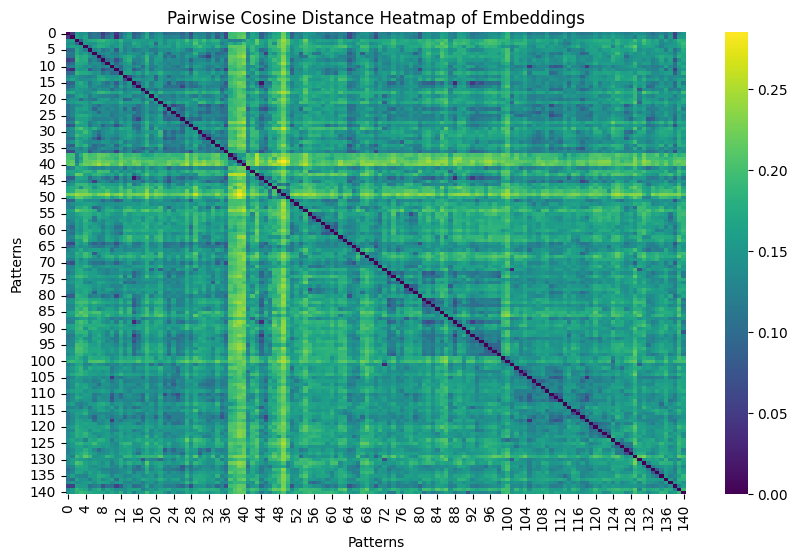

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(distances, cmap='viridis')
plt.title('Pairwise Cosine Distance Heatmap of Embeddings')
plt.xlabel('Patterns')
plt.ylabel('Patterns')
plt.show()

In [50]:
removable_indices = set()
new_patterns = []

In [128]:
embeddings = data[features_cols]
pattern_data = data[pattern_cols]

In [129]:
embeddings = embeddings.drop(removable_indices, axis=0).reset_index(drop=True)
distances = pairwise_distances(embeddings, metric='cosine')

In [130]:
print(embeddings.shape)
print(distances.shape)
print(pattern_data.shape)

(345, 3072)
(345, 345)
(349, 6)


In [131]:
def remove_pattern(pattern_index):
    global embeddings, pattern_data
    embeddings = embeddings.drop(pattern_index, axis=0).reset_index(drop=True)
    pattern_data = pattern_data.drop(pattern_index, axis=0).reset_index(drop=True)

In [132]:
distance_threshold = 0.03
distance_threshold_llm = 0.08
break_point = 5
for i, row in tqdm(enumerate(distances),desc="Comparing Patterns"):

    print(i,"Pattern: ", end="")
    print(pattern_data.iloc[i]["Pattern Name"], end=" --> ")
    print(np.argsort(row)[1],pattern_data.iloc[np.argsort(row)[1]]["Pattern Name"], f"(Distance: {row[np.argsort(row)[1]]:.4f})")

    if row[np.argsort(row)[1]] > distance_threshold or i in removable_indices or np.argsort(row)[1] in removable_indices:     
        if row[np.argsort(row)[1]] <= distance_threshold_llm:
            pattern_01_df,pattern_02_df = pd.DataFrame(columns=pattern_cols, data=[pattern_data.iloc[i]]), pd.DataFrame(columns=pattern_cols, data=[pattern_data.iloc[np.argsort(row)[1]]])
            pattern_01_dict,pattern_02_dict = df_to_pattern_dict(pattern_01_df),df_to_pattern_dict(pattern_02_df)
            print("Comparing patterns are:\n", pattern_01_dict, "\n", pattern_02_dict)
            result = compare_patterns(pattern_01_dict, pattern_02_dict)
            if result.get("remove") == "pattern 01":
                removable_indices.add(i)
            elif result.get("remove") == "pattern 02":
                removable_indices.add(int(np.argsort(row)[1]))
            elif result.get("remove") == "both":
                removable_indices.add(i)
                removable_indices.add(int(np.argsort(row)[1]))
            
            if result.get("can_combine") == True:
                new_patterns.append(result.get("combined_pattern_suggestion"))

            # if break_point <= 0:
            #     break
            # break_point -= 1
        continue
    removable_indices.add(int(np.argsort(row)[1]))
remove_pattern(removable_indices)
distances = pairwise_distances(embeddings, metric='cosine')
removable_indices = set()

Comparing Patterns: 0it [00:00, ?it/s]

0 Pattern: External Knowledge Augmentation --> 87 Perceiver (Feedback Processing) (Distance: 0.0728)
Comparing patterns are:
 {'Pattern Name': 'External Knowledge Augmentation', 'Problem': 'Large Language Models (LLMs) are bounded by their pretraining knowledge, lack the ability to acquire updated information, and are prone to generating factually inaccurate or outdated content (hallucination).', 'Context': 'LLMs relying on fixed and parametric knowledge, often struggling with contemporary or specific factual queries.', 'Solution': 'Augment LLMs with the capability to access external tools such as search engines, databases, and knowledge graphs to dynamically acquire and integrate external knowledge.', 'Result': 'LLMs can surpass traditional knowledge limitations, offering more accurate and contextually relevant outputs by accessing real-time and structured information.', 'Uses': 'Accessing contemporary information, retrieving specific information from structured databases, executing c

Comparing Patterns: 1it [00:20, 20.57s/it]

1 Pattern: Domain-Specific Tool Integration --> 87 Perceiver (Feedback Processing) (Distance: 0.1002)
2 Pattern: Task Automation via Tools --> 147 ReAct (Reasoning and Acting) (Distance: 0.0852)
3 Pattern: Multimodal Interaction Augmentation --> 67 Swap-Out-Only-Once Cache Strategy (Distance: 0.0831)
4 Pattern: Transparent Tool-Use Reasoning --> 146 Tool Orchestration / Chaining (Distance: 0.0688)
Comparing patterns are:
 {'Pattern Name': 'Transparent Tool-Use Reasoning', 'Problem': "The opaque 'black-box' nature of current LLMs does not reveal their decision-making process, leading to skepticism about response reliability, difficulty in identifying errors, and a lack of trust, especially in high-stakes domains.", 'Context': 'LLM applications where interpretability, accountability, and user trust are paramount.', 'Solution': 'Utilize tool learning to enable LLMs to exhibit each step of their decision-making process, including the rationale behind tool selection, parameter extraction, a

Comparing Patterns: 5it [00:34,  6.05s/it]

...

Comparing Patterns: 343it [34:17,  5.28s/it]

343 Pattern: Dense Passage Retrieval (DPR) --> 342 Marginalization over Latent Documents (Distance: 0.0610)
Comparing patterns are:
 {'Pattern Name': 'Dense Passage Retrieval (DPR)', 'Problem': 'Efficiently and effectively retrieving relevant text passages from a large corpus based on a query, especially for knowledge-intensive tasks, where simple keyword matching (like BM25) might be insufficient.', 'Context': 'Open-domain question answering, fact verification, or any knowledge-intensive NLP task requiring semantic matching between a query and a vast collection of documents to find relevant evidence.', 'Solution': "Employ a bi-encoder architecture where a query encoder (e.g., BERT-based) produces a dense vector representation of the query, and a document encoder (e.g., BERT-based) produces dense vector representations for all documents. Retrieval is then performed by finding documents whose dense representations have the highest inner product similarity with the query's dense represen

Comparing Patterns: 344it [34:25,  5.73s/it]

344 Pattern: Denoising Sequence-to-Sequence Pretraining (BART-like) --> 336 Retrieval-Augmented Generation (RAG) (Distance: 0.0595)
Comparing patterns are:
 {'Pattern Name': 'Denoising Sequence-to-Sequence Pretraining (BART-like)', 'Problem': 'Training a robust and versatile sequence-to-sequence model that can perform well across a diverse set of generation, translation, and comprehension tasks, and serve as a strong parametric memory component in hybrid systems.', 'Context': 'Developing a general-purpose language model capable of both understanding and generating text, often used as a base for fine-tuning on specific downstream tasks.', 'Solution': 'Pretrain an encoder-decoder transformer model using a denoising objective. This involves corrupting text with various noising functions (e.g., token masking, token deletion, text infilling, sentence permutation) and then training the model to reconstruct the original uncorrupted text. The encoder processes the corrupted input, and the deco

Comparing Patterns: 345it [34:36,  6.02s/it]


In [ ]:
# 15 Pattern: Retrieval Augmented Generation (RAG) --> 123 Retrieval Augmented Generation (RAG) (Distance: 0.0199)
# 18 Pattern: Chain of Thought (CoT) Prompting --> 116 Chain-of-Thought (CoT) Prompting (Distance: 0.0097)
# 148 Pattern: Chain-of-Thought (CoT) Prompting --> 18 Chain of Thought (CoT) Prompting (Distance: 0.0118)

set()

In [134]:
len(new_patterns)

62

### Clustering

In [113]:
dbscan = DBSCAN(eps=0.08, min_samples=1, metric='cosine')
clusters = dbscan.fit_predict(embeddings)
len(set(clusters.tolist()))

179

In [111]:
for i,row in enumerate(clusters):
    print(f"{i} Pattern: {Y[i]} --> Cluster: {row}")

0 Pattern: External Knowledge Augmentation --> Cluster: 0
1 Pattern: Domain-Specific Tool Integration --> Cluster: 0
2 Pattern: Task Automation via Tools --> Cluster: 0
3 Pattern: Multimodal Interaction Augmentation --> Cluster: 1
4 Pattern: Transparent Tool-Use Reasoning --> Cluster: 2
5 Pattern: Robust Tool-Augmented Processing --> Cluster: 0
6 Pattern: Iterative Task Solving (with Feedback) --> Cluster: 3
7 Pattern: Task Decomposition and Planning --> Cluster: 0
8 Pattern: Tool Retrieval and Selection --> Cluster: 4
9 Pattern: Parameter Extraction and Tool Invocation --> Cluster: 5
10 Pattern: Tool-Augmented Response Synthesis --> Cluster: 6
11 Pattern: LLM as Tool Maker/Creator --> Cluster: 7
12 Pattern: Sufficient Context Autorater --> Cluster: 8
13 Pattern: Selective Generation with Sufficient Context Signal --> Cluster: 8
14 Pattern: Finetuning for Controlled Abstention --> Cluster: 8
15 Pattern: Retrieval Augmented Generation (RAG) --> Cluster: 0
16 Pattern: LLM-based Evaluatio